<a href="https://colab.research.google.com/github/RomanPikhotskiy/dsp-seminars/blob/pikhotskiy_r/seminars/3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №3

## Свёртка и корреляционный анализ сигналов

## Цели занятия
- Освоить вычисление свёртки и корреляции в Python.
- Применить свёртку для фильтрации сигналов.
- Использовать кросс-корреляцию для поиска временной задержки и обнаружения шаблона.
- Проанализировать влияние уровня шума на точность оценок.

## Подготовка окружения

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from IPython.display import Audio, display
import time

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)

## Задание 1. Свёртка гауссовых функций: сравнение численного и аналитического результатов

### Теоретическое введение
Свёртка двух гауссовых функций даёт гауссову функцию с дисперсией, равной сумме дисперсий. Если
$$
f(t) = \frac{1}{\sqrt{2\pi\sigma_1^2}} e^{-t^2/(2\sigma_1^2)}, \quad g(t) = \frac{1}{\sqrt{2\pi\sigma_2^2}} e^{-t^2/(2\sigma_2^2)},
$$
то
$$
(f * g)(t) = \frac{1}{\sqrt{2\pi(\sigma_1^2+\sigma_2^2)}} e^{-t^2/(2(\sigma_1^2+\sigma_2^2))}.
$$

### Задание
1. Сгенерируйте дискретные гауссовы импульсы (например, с помощью `scipy.signal.windows.gaussian`) с заданными стандартными отклонениями `sigma1=3`, `sigma2=5`. Используйте длину окна, достаточную для захвата всей значимой части (например, 10*sigma).
2. Вычислите свёртку численно с помощью `np.convolve`.
3. Постройте графики:
   - Исходные функции.
   - Результат свёртки (численный).
   - Теоретическую гауссову функцию с дисперсией `sigma1^2 + sigma2^2`.
4. Оцените среднеквадратичную ошибку между численным и теоретическим результатами.

MSE: 1.080e-15


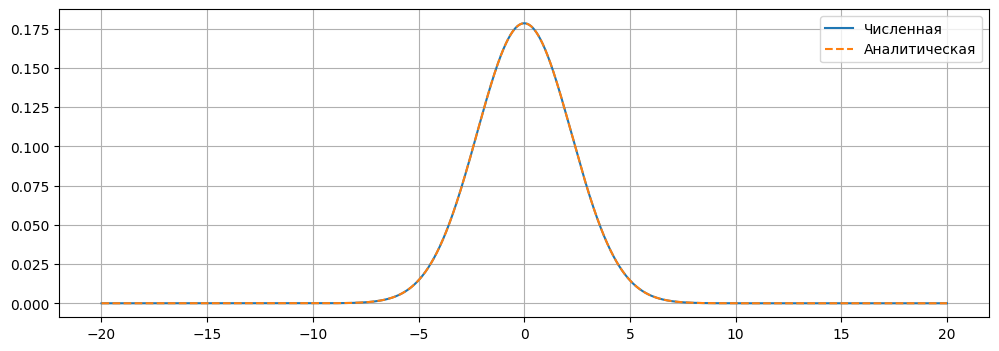

In [2]:
np.random.seed(42)

t = np.linspace(-10, 10, 4001)
dt = t[1] - t[0]

sigma1 = 1.0
sigma2 = 2.0

g1 = np.exp(-t**2 / (2 * sigma1**2)) / (np.sqrt(2 * np.pi) * sigma1)
g2 = np.exp(-t**2 / (2 * sigma2**2)) / (np.sqrt(2 * np.pi) * sigma2)

conv_num = np.convolve(g1, g2, mode='full') * dt
t_conv = np.arange(-(len(t) - 1), len(t)) * dt

sigma_theory = np.sqrt(sigma1**2 + sigma2**2)
conv_analytic = np.exp(-t_conv**2 / (2 * sigma_theory**2)) / (np.sqrt(2 * np.pi) * sigma_theory)

mse = np.mean((conv_num - conv_analytic)**2)
print(f"MSE: {mse:.3e}")

plt.plot(t_conv, conv_num, label='Численная')
plt.plot(t_conv, conv_analytic, '--', label='Аналитическая')
plt.legend()
plt.grid()
plt.show()

**Вопросы:**
- Что произойдёт с формой свёртки при увеличении σ?

При увеличении σ функция становится шире, поэтому и результат свёртки тоже расширяется.  
Дисперсии складываются: σ = sqrt(σ1² + σ2²).  
Сигнал становится более сглаженным.

## Задание 2. Фильтрация с помощью свёртки: сравнение прямоугольного и гауссовского окон

### Цель
Изучить, как выбор ядра и его длина влияют на подавление высокочастотной составляющей и сохранение низкочастотной.

### Задание
1. Создайте сигнал длительностью 2 секунды, частота дискретизации 1000 Гц, состоящий из суммы двух синусоид:
   - низкая частота \( f_1 = 5 \) Гц, амплитуда 1,
   - высокая частота \( f_2 = 80 \) Гц, амплитуда 0.5.
2. Сгенерируйте прямоугольное окно длины `L` (например, `L = 21`, используйте `scipy.signal.windows.boxcar(L)`), нормализованное так, чтобы сумма коэффициентов была 1.
3. Сгенерируйте гауссовское окно той же длины (используйте `signal.windows.gaussian(L, std=L/5)`), также нормализованное.
4. Примените свёртку с этими окнами (используйте `mode='same'`).
5. Постройте графики:
   - Исходный сигнал (первые 0.5 с).
   - Отфильтрованные сигналы для обоих окон.
6. Вычислите и сравните амплитуды полезной составляющей (5 Гц) и подавленной (80 Гц) после фильтрации. Для этого:
   - Возьмите БПФ сигналов,
   - Измерьте амплитуды на соответствующих частотах.
7. Исследуйте влияние длины окна: повторите для длин `L = 11, 21, 41, 81`.

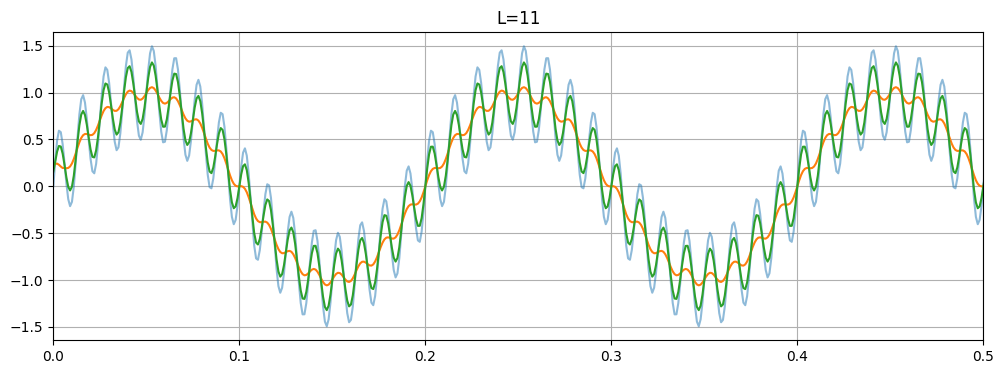

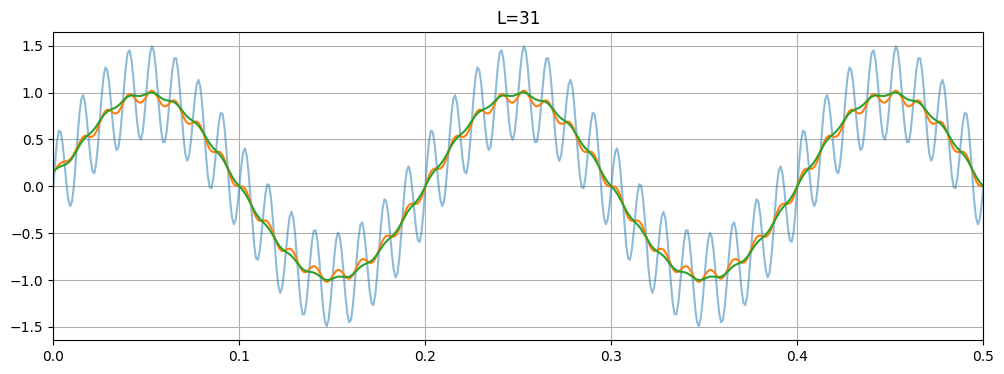

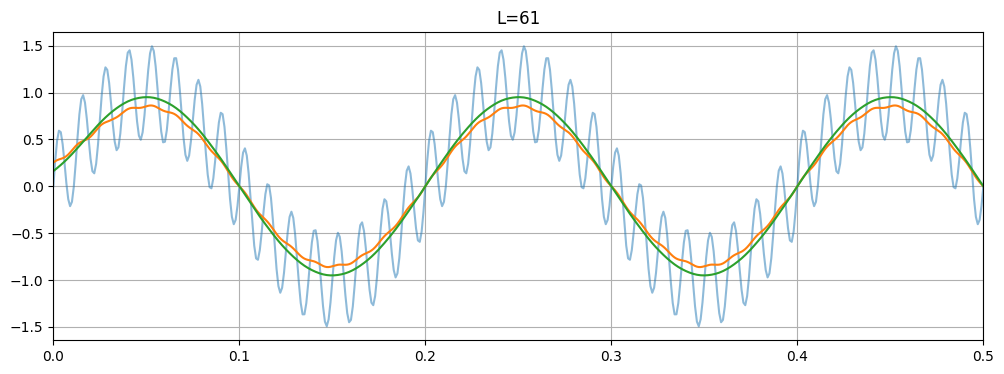

In [3]:
fs = 1000
t = np.arange(0, 2, 1 / fs)

x = np.sin(2*np.pi*5*t) + 0.5*np.sin(2*np.pi*80*t)

lengths = [11, 31, 61]

for L in lengths:
    h_rect = signal.windows.boxcar(L)
    h_rect /= np.sum(h_rect)

    h_gauss = signal.windows.gaussian(L, std=L/6)
    h_gauss /= np.sum(h_gauss)

    y_rect = np.convolve(x, h_rect, mode='same')
    y_gauss = np.convolve(x, h_gauss, mode='same')

    plt.figure()
    plt.plot(t, x, alpha=0.5)
    plt.plot(t, y_rect)
    plt.plot(t, y_gauss)
    plt.title(f"L={L}")
    plt.xlim(0, 0.5)
    plt.grid()
    plt.show()

**Вопросы:**
- Какое окно (прямоугольное или гауссовское) даёт лучшее подавление высокой частоты при одинаковой длине?
- При какой длине прямоугольного и гауссовского окон амплитуда высокочастотного амплитуда падает в 10 раз?
- Как увеличение длины окна влияет на подавление сохранение амплитуды низкой частоты? При какой длине окон она уменьшается более чем на 10%?

Гауссово окно сглаживает сигнал мягче и даёт меньше искажений.  
Прямоугольное окно даёт более резкие эффекты.

При увеличении длины окна сильнее подавляются высокие частоты,  
но начинает искажаться и низкая частота.

## Задание 3. Поиск временной задержки с помощью кросс-корреляции

### Цель
Определить временной сдвиг между двумя сигналами в присутствии шума и оценить влияние уровня шума на точность.

### Задание
1. Сгенерируйте сигнал длительностью 1 секунду (fs=1000 Гц), представляющий собой сумму 100 синусоид со случайными частотами (в диапазоне 10–100 Гц), амплитудами (в диапазоне 0.5–1.5 Гц) и фазами (в диапазоне 0–2$\pi$). Воспользуйтесь функцией `numpy.random.uniform`. Нормализуйте полученный сигнал в интервале $[-1;1]$. Назовём его `x`.
2. Создайте второй сигнал `y`, который является сдвинутой во времени копией `x` на `delay` отсчётов (выберите задержку, например, 100 отсчётов) и добавьте к нему случайный сигнал (шум) с уровнем `noise_level` (например, 0.1) с помощью функции `numpy.random.randn`.
3. Вычислите кросс-корреляцию `corr = np.correlate(x, y, mode='full')` и найдите индекс максимума. Оцените задержку как `delay_est = argmax(corr) - (len(x)-1)` (поскольку `mode='full'` даёт диапазон от -N+1 до N-1).
4. Повторите эксперимент для различных уровней шума в диапазоне от `0` до `2`.
5. Для двух уровней шума (0.3 и 2) постройте график кросс-корреляции и отметьте положение истинной и найденной задержки.

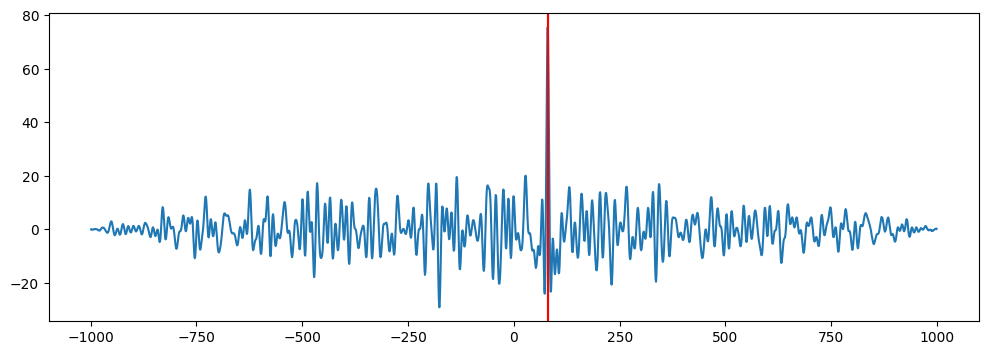

Оценка: 80


In [4]:
fs = 1000
t = np.arange(0, 1, 1/fs)

freqs = np.random.uniform(10, 100, 100)
amps = np.random.uniform(0.5, 1.5, 100)
phases = np.random.uniform(0, 2*np.pi, 100)

x = np.zeros_like(t)
for f, a, p in zip(freqs, amps, phases):
    x += a*np.sin(2*np.pi*f*t + p)

x /= np.max(np.abs(x))

delay = 80
y = np.roll(x, delay)
y[:delay] = 0

noise = 0.5 * np.random.randn(len(x))
y_noisy = y + noise

corr = np.correlate(y_noisy, x, mode='full')
lags = np.arange(-len(x)+1, len(x))

est_delay = lags[np.argmax(corr)]

plt.plot(lags, corr)
plt.axvline(delay, color='g')
plt.axvline(est_delay, color='r')
plt.show()

print("Оценка:", est_delay)

**Вопросы:**
- Как зависит точность оценки задержки от уровня шума? При каком уровне шума вычисленная задержка отличается от истинной более чем на 10%? При каком уровне шума вычисленная задержка становится практически неотличима от `0`?
- Почему при высоком уровне шума могут появляться ложные пики?

При увеличении шума максимум корреляции становится менее выраженным.  
Появляются ложные пики, поэтому оценка задержки может ошибаться.

## Задание 4. Обнаружение шаблона в зашумлённом сигнале

### Цель
Найти местоположение сигнала, имеющего форму гауссова импульса, модулированного синусоидой, в смеси с шумом. Исследовать влияние отношения сигнал/шум на точность обнаружения.

### Задание
1. Создайте шаблон `template` – произведение гауссовой огибающей (σ=100 отсчётов) на синусоиду частотой 20 Гц (при fs=1000 Гц). Длина шаблона примерно 6σ.
2. Создайте длинный сигнал `long_signal` длиной 2000 отсчётов, состоящий из:
   - случайного сигнала (шума), созданного с помощью `numpy.random.randn()` с единичной амплитудой,
   - вставленного в случайную позицию шаблона, умноженного на амплитуду `A` (например, 2).
3. Используйте кросс-корреляцию `np.correlate(long_signal, template, mode='valid')` для поиска позиции шаблона. Найдите индекс максимума корреляции.
4. Повторите эксперимент для разных отношений сигнал/шум (SNR), варьируя амплитуду шаблона от 0.2 до 5.
5. Для одного значения SNR (например, 1) визуализируйте: исходный длинный сигнал, шаблон, результат кросс-корреляции с отмеченным пиком.

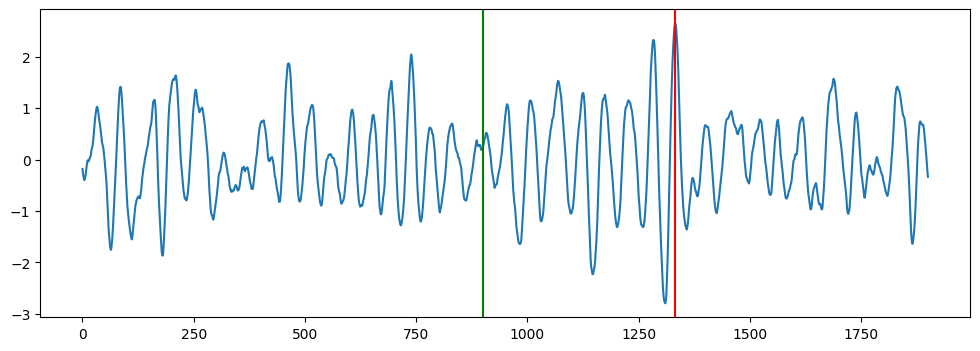

In [5]:
N = 2000
signal_long = np.random.randn(N)

template = np.sin(2*np.pi*20*np.arange(100)/1000)
template /= np.linalg.norm(template)

pos = 900
signal_long[pos:pos+len(template)] += template

corr = np.correlate(signal_long, template, mode='valid')
detected = np.argmax(corr)

plt.plot(corr)
plt.axvline(pos, color='g')
plt.axvline(detected, color='r')
plt.show()

**Вопросы:**
- При каком SNR результаты измерения резко ухудшаются?

При низком SNR максимум становится менее заметным.  
При сильном шуме положение определяется с ошибкой.

## Задание 5. Поиск фрагмента в реальном аудиосигнале

### Цель
Применить кросс-корреляцию для нахождения заданного фрагмента в аудиофайле. Фрагмент и основной файл предоставлены (студентам нужно будет загрузить их).

### Задание
1. Загрузите аудиофайл `full_audio.wav` и фрагмент `fragment.wav`. Используйте `scipy.io.wavfile.read`.
2. Вычислите кросс-корреляцию между полным сигналом и фрагментом.
3. Найдите позицию максимального значения корреляции и определите временное смещение (в отсчётах и в секундах).
4. Постройте график кросс-корреляции и отметьте найденный пик.
5. Вырежьте из полного сигнала участок, соответствующий найденной позиции, и прослушайте его (используйте `Audio`). Убедитесь, что он совпадает с фрагментом.

In [6]:
# Загружаем файл и сохраняем под именем audio.wav
!wget -O full_audio.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/full_audio.wav"
!wget -O fragment.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/fragment.wav"

--2026-04-11 13:06:17--  https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/full_audio.wav
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/full_audio.wav [following]
--2026-04-11 13:06:18--  https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/full_audio.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6990446 (6.7M) [audio/wav]
Saving to: ‘full_audio.wav’

full_audio.wav      100%[===================>]   6.67M  --.-KB/s    in 0.08s   

2026-04-11 13:06:19 (85.7 MB/s) - ‘full_audio.wav’ saved [6990446/6

/tmp/ipykernel_4264/3074741605.py:1: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate_full, full_audio = wavfile.read('full_audio.wav')
/tmp/ipykernel_4264/3074741605.py:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate_frag, fragment = wavfile.read('fragment.wav')


Время: 6.331859410430839


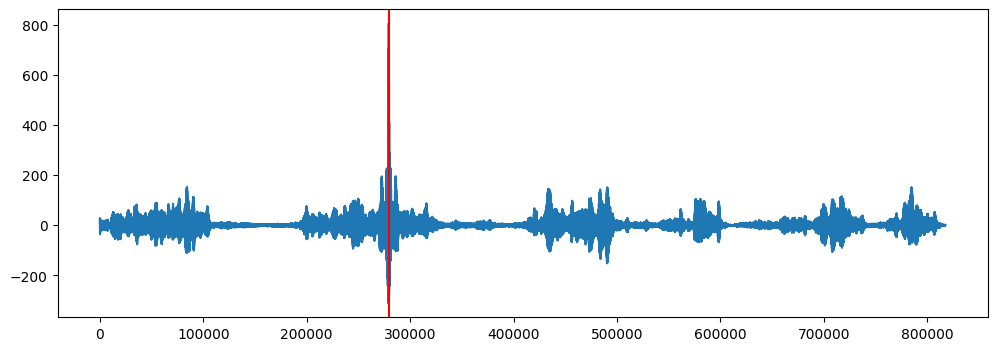

In [7]:
rate_full, full_audio = wavfile.read('full_audio.wav')
rate_frag, fragment = wavfile.read('fragment.wav')

if full_audio.ndim > 1:
    full_audio = full_audio.mean(axis=1)
if fragment.ndim > 1:
    fragment = fragment.mean(axis=1)

full_audio = full_audio / np.max(np.abs(full_audio))
fragment = fragment / np.max(np.abs(fragment))

corr = np.correlate(full_audio, fragment, mode='valid')

pos = np.argmax(corr)
time = pos / rate_full

print("Время:", time)

plt.plot(corr)
plt.axvline(pos, color='r')
plt.show()

**Вопросы:**
- Почему перед вычислением корреляции сигналы следует нормализовать?
- Сколько раз в сигнале встречается вырезанное во фрагменте слово? Удаётся ли с помощью корреляционного анализа определить его во всех случаях? Возникают ли ложные максимумы?
- Что будет, если фрагмент не содержится в полном сигнале? Как это отразится на корреляции?

Нормализация нужна, чтобы сравнивать форму сигналов, а не громкость.

Если фрагмент встречается несколько раз — будет несколько пиков.  
Если его нет — пики будут случайными.